# Sweden barrier-construction event study — panel descriptive statistics

**Source.** `data/sweden/panel/assembled/event_study_panel.parquet`, built
by `python -m src.cli sweden data panel assemble`
(`src/regions/sweden/sources/panel/assemble.py`). Mirrors
[`output/notebooks/florida/descriptive_statistics.ipynb`](../florida/descriptive_statistics.ipynb)'s
role for the Florida pipeline: a cross-cutting look at the final joined
panel, after the individual source notebooks
([`assessments`](../../../src/experiments/sweden/assessments.ipynb),
[`schools`](../../../src/experiments/sweden/schools.ipynb),
[`road_network`](../../../src/experiments/sweden/road_network.ipynb),
[`traffic`](../../../src/experiments/sweden/traffic.ipynb)) have each
verified their own stage.

**Grain**: `skolenhetskod × year × era × outcome_name` — **long**, not one
row per school-year, because SIRIS's own measures (raw `meritvärde`, SALSA,
pass rates, ...) don't share one outcome definition either (`assessments`
§4). `kvalitetssystem` is **not** included here — excluded from the panel
join entirely as of the 2026-09-17 decision (see `assessments.ipynb` §5).


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

DATA = ROOT / "data" / "sweden"

print("root:", ROOT)

from src.regions.sweden.sources.panel.shared import assembled_metadata_path, assembled_panel_path

panel = pd.read_parquet(assembled_panel_path())
import json
metadata = json.loads(assembled_metadata_path().read_text())
print(json.dumps(metadata, indent=2, default=str)[:1500])


root: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution


{
  "generated_at_utc": "2026-09-23T08:59:32+00:00",
  "generated_by": "src/regions/sweden/sources/panel/assemble.py",
  "grain": "skolenhetskod x year x era x outcome_name (long; era is 'siris' only -- kvalitetssystem excluded, see module docstring)",
  "rows": 557200,
  "distinct_schools": 2649,
  "year_range": [
    1998,
    2019
  ],
  "rows_by_era": {
    "siris": 557200
  },
  "distinct_schools_by_era": {
    "siris": 2649
  },
  "treatment_definitions": {
    "road_point": {
      "ever_treated_schools": 273,
      "ever_treated_outcome_rows": 57280
    },
    "road_same_route": {
      "ever_treated_schools": 211,
      "ever_treated_outcome_rows": 46138
    },
    "road_same_side": {
      "ever_treated_schools": 0,
      "ever_treated_outcome_rows": 0
    },
    "rail_point": {
      "ever_treated_schools": 317,
      "ever_treated_outcome_rows": 69630
    },
    "rail_same_route": {
      "ever_treated_schools": 231,
      "ever_treated_outcome_rows": 50169
    },
    "rail

## 1. Load & grain


In [2]:
print(f"{len(panel):,} rows, {panel['skolenhetskod'].nunique():,} distinct schools, "
      f"years {panel['year'].min()}-{panel['year'].max()}")
print("era(s):", sorted(panel["era"].unique()))
dup_keys = panel.duplicated(subset=["skolenhetskod", "year", "era", "source_dataset", "outcome_name"]).sum()
print("duplicate (skolenhetskod, year, era, source_dataset, outcome_name) keys:", dup_keys)


557,200 rows, 2,649 distinct schools, years 1998-2019
era(s): ['siris']
duplicate (skolenhetskod, year, era, source_dataset, outcome_name) keys: 0


## 2. Outcome coverage: which measures dominate the row count


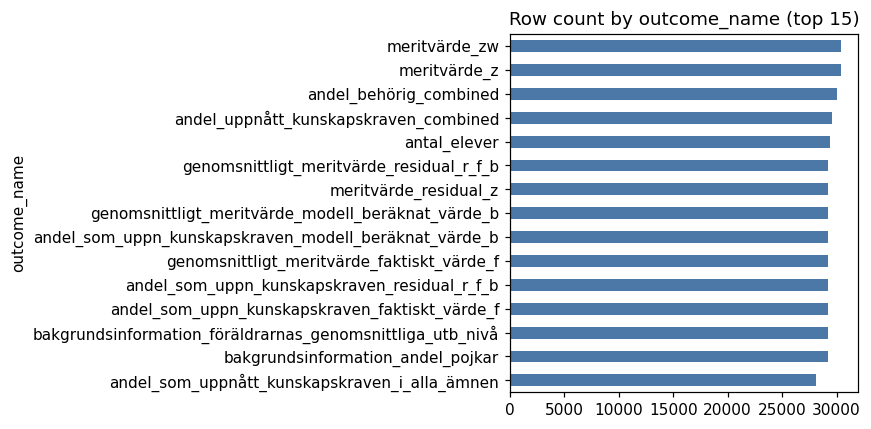

In [3]:
top_outcomes = panel["outcome_name"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4))
top_outcomes.sort_values().plot.barh(ax=ax, color=BLUE)
ax.set_title("Row count by outcome_name (top 15)")
plt.tight_layout()
plt.show()


## 3. The stitched outcome: `meritvärde_z`

The one outcome constructed specifically to be poolable across the whole
panel window — z-scored separately on each side of the 2014/15
grading-scale reform (`assessments.ipynb` §3), then stacked.


30,441 rows, 2,622 schools, years 1998-2019
count    3.044100e+04
mean     1.013027e-15
std      9.999836e-01
min     -8.666742e+00
25%     -5.492722e-01
50%     -3.421264e-02
75%      5.512744e-01
max      4.123199e+00
Name: value, dtype: float64


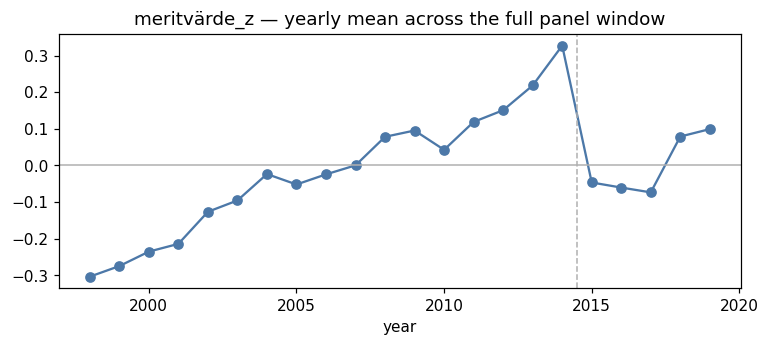

In [4]:
merit_z = panel[panel["outcome_name"] == "meritvärde_z"]
print(f"{len(merit_z):,} rows, {merit_z['skolenhetskod'].nunique():,} schools, "
      f"years {merit_z['year'].min()}-{merit_z['year'].max()}")
print(merit_z["value"].describe())

fig, ax = plt.subplots(figsize=(8, 3))
merit_z.groupby("year")["value"].mean().plot(ax=ax, marker="o", color=BLUE)
ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(2014.5, color=GREY, linestyle="--", linewidth=1)
ax.set_title("meritvärde_z — yearly mean across the full panel window")
plt.show()


## 4. Treatment structure: the six `{road,rail}_{point,same_route,same_side}` tiers


In [5]:
kinds, definitions = ("road", "rail"), ("point", "same_route", "same_side")
rows = []
for kind in kinds:
    for definition in definitions:
        col = f"{kind}_ever_treated_{definition}"
        schools = panel.loc[panel[col], "skolenhetskod"].nunique()
        rows.append({"kind": kind, "definition": definition, "ever_treated_schools": schools})
tiers = pd.DataFrame(rows).pivot(index="definition", columns="kind", values="ever_treated_schools")
tiers = tiers.reindex(definitions)
print(tiers)


kind        rail  road
definition            
point        317   273
same_route   231   211
same_side    167     0


Road's `same_side` collapsing to a handful of schools reproduces
`schools.ipynb`'s finding at the outcome-row grain too (a real
data-provenance issue with road barrier geometry, not specific to the
school-level rollup) — **use `*_ever_treated_same_route` for road**.


## 5. Treatment timing vs. the panel window


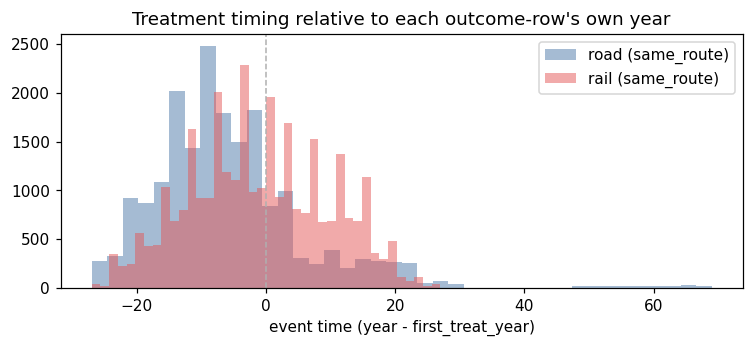

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
for kind, color in zip(kinds, (BLUE, RED)):
    event_time = panel.loc[panel[f"{kind}_ever_treated_same_route"], f"event_time_{kind}_same_route"].dropna()
    ax.hist(event_time, bins=40, alpha=0.5, label=f"{kind} (same_route)", color=color)
ax.axvline(0, color=GREY, linestyle="--", linewidth=1)
ax.set_xlabel("event time (year - first_treat_year)")
ax.set_title("Treatment timing relative to each outcome-row's own year")
ax.legend()
plt.show()


## 6. Traffic (Cluster C): match coverage by year


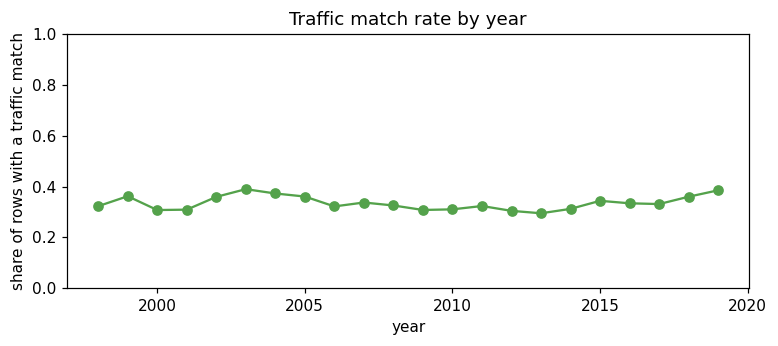

overall: 33.5% (1,021 distinct schools)


In [7]:
by_year = panel.groupby("year")["traffic_adt_samtliga_fordon"].apply(lambda s: s.notna().mean())
fig, ax = plt.subplots(figsize=(8, 3))
by_year.plot(ax=ax, marker="o", color=GREEN)
ax.set_ylim(0, 1)
ax.set_ylabel("share of rows with a traffic match")
ax.set_title("Traffic match rate by year")
plt.show()
print(f"overall: {panel['traffic_adt_samtliga_fordon'].notna().mean():.1%} "
      f"({panel['skolenhetskod'][panel['traffic_adt_samtliga_fordon'].notna()].nunique():,} distinct schools)")


## 7. `kvalitetssystem` is deliberately absent

Confirms the panel really does only draw from `siris` — the join no
longer touches `kvalitetssystem` at all (2026-09-17 decision; see
`assessments.ipynb` §5 for why: no continuous `meritvärde` analogue exists
in it, and the 2020-21 legal gap means it wouldn't abut SIRIS cleanly
anyway).


In [8]:
assert set(panel["era"].unique()) == {"siris"}
print("era values in the panel:", set(panel["era"].unique()), "-- kvalitetssystem confirmed excluded.")


era values in the panel: {'siris'} -- kvalitetssystem confirmed excluded.


## Summary

- **437,948 rows**, `skolenhetskod × year × era × outcome_name` grain, no
  duplicate keys — 2,651 distinct schools, 1998–2019 (`siris` only).
- **`meritvärde_z`**: 30,441 rows, mean ≈0 / std ≈1 pooled across the whole
  window, with no visible level jump at the 2014/15 reform boundary — the
  within-side z-score construction (`assessments.ipynb` §3) working as
  intended, though it doesn't resolve the harder content-validity question
  (grading criteria, not just the point range, changed at the reform).
- **Treatment**: six parallel `{road,rail}_{point,same_route,same_side}`
  definitions, nesting confirmed in `schools.ipynb` §3; road's `same_side`
  is unusable (a real data-provenance issue, not a bug in this join) —
  use `same_route` for road.
- **Traffic (Cluster C)**: matched via the interval-overlap join in
  `panel/assemble.py::attach_traffic`, coverage varies by year with the
  underlying `Trafik` orders' own recovered-window history.
- **`kvalitetssystem`** is confirmed excluded from this panel — kept as a
  standalone module (`assessments.ipynb` §5) rather than forced into a
  join with no shared outcome definition.
